In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yapss
from yapss import math

In [2]:
import time

In [3]:
start_time = time.perf_counter()
# Start/End
start_state = [0, 0, 0, 0]
goal_states = np.array([[50, 50, 0, 0],
               [50, 250, 100, 0]])

# Collectively define the number of phases the problem will have in total
constraints = len(goal_states)
phases_per_constraint = 3
total_phases = constraints*phases_per_constraint
last_phase_idx = total_phases-1

# Ardupilot limits from full params list, input as displayed in MP (no negatives)
V_max = 30
V_min = 10
V_cruise = 22
max_climb = 5
max_desc = 5
roll_limit = 65
roll_min = 5 # From level_roll_limit

# Adjust weights for optimization (final time, inv. turn radius, difference from cruise velocity, climb/desc rate)
W_t = 1
W_r = 1
W_v = 1
W_c = 1

# Set the spatial tolerance of the constraints, cannot be 0 or problem is too stiff
spatial_tolerance = 1

# Extrapolated limits
roll_min_rad = math.deg2rad(roll_min)
roll_limit_rad = math.deg2rad(roll_limit)
max_turn = V_cruise**2/(9.81*math.tan(roll_min_rad))
min_turn = V_cruise**2/(9.81*math.tan(roll_limit_rad))

end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time:.6f} seconds")

Elapsed time: 0.000394 seconds


In [4]:
start_time = time.perf_counter()

problem = yapss.Problem(name = "Constraint to Waypoints",
                        nx = [4]*total_phases,
                        ns = 3*total_phases,
                        nd = 5*(total_phases - 1))

def objective(arg):
    param = arg.parameter
    objective = W_t*arg.phase[last_phase_idx].final_time**2
    for p in range(total_phases):
        objective += W_r*param[3*p]**2 + W_v*(param[3*p+1] - V_cruise)**2 + W_c*param[3*p+2]**2
    arg.objective = objective

def continuous(arg):
    params = arg.parameter
    for p in range(total_phases):
        x, y, z, phi = arg.phase[p].state
        r_inv, V, omega = params[3*p:3*p+3]
        xdot = V*math.cos(phi)
        ydot = V*math.sin(phi)
        zdot = omega
        phidot = V*r_inv
        arg.phase[p].dynamics = [xdot, ydot, zdot, phidot]

def discrete(arg):
    discrete = []
    for p in range(last_phase_idx):
        discrete.append(arg.phase[p].final_time - arg.phase[p+1].initial_time)
        discrete.extend(arg.phase[p].final_state - arg.phase[p+1].initial_state)
    arg.discrete = discrete

problem.functions.objective = objective
problem.functions.continuous = continuous
problem.functions.discrete = discrete

for p in range(total_phases):
    problem.bounds.phase[p].initial_time.lower = 0
    problem.bounds.parameter.lower[3*p] = -1/min_turn
    problem.bounds.parameter.upper[3*p] = 1/min_turn
    problem.bounds.parameter.lower[3*p+1] = V_min
    problem.bounds.parameter.upper[3*p+1] = V_max
    problem.bounds.parameter.lower[3*p+2] = -max_desc
    problem.bounds.parameter.upper[3*p+2] = max_climb
    problem.guess.phase[p].time = [0, 1]
problem.bounds.discrete.lower[:] = problem.bounds.discrete.upper[:] = 0

problem.bounds.phase[0].initial_time.upper = 0
problem.bounds.phase[0].initial_state.lower = problem.bounds.phase[0].initial_state.upper = start_state
for i in range(constraints):
    problem.bounds.phase[(i+1)*phases_per_constraint-1].final_state.lower[0:3] = goal_states[i,0:3] - np.array([spatial_tolerance]*3)
    problem.bounds.phase[(i+1)*phases_per_constraint-1].final_state.upper[0:3] = goal_states[i,0:3] + np.array([spatial_tolerance]*3)
    problem.bounds.phase[(i+1)*phases_per_constraint-1].final_state.upper[3] = problem.bounds.phase[(i+1)*phases_per_constraint-1].final_state.lower[3] = 0

segments, points = 10, 10
problem.mesh.phase[0].collocation_points = segments * [points]
problem.mesh.phase[0].fraction = segments * [1 / segments]
problem.ipopt_options.tol = 1e-8

problem.ipopt_options.print_user_options = "no"
problem.ipopt_options.print_level = 0

end_time = time.perf_counter()

print(f"Elapsed time: {end_time - start_time:.6f} seconds")

sol = problem.solve()

Elapsed time: 0.002091 seconds


In [5]:
t_sol = []
t_phase_sol = []
x_sol = []
y_sol = []
z_sol = []
phi_sol = []
phi_deg_sol = []
r_inv_sol = []
r_sol = []
V_sol = []
omega_sol = []
for p in range(total_phases):
    t_temp = sol.phase[p].time
    t_phase_sol.append(t_temp[0])
    if p == last_phase_idx:
        t_phase_sol.append(t_temp[-1])
    x_temp, y_temp, z_temp, phi_temp = sol.phase[p].state
    t_sol.extend(t_temp)
    x_sol.extend(x_temp)
    y_sol.extend(y_temp)
    z_sol.extend(z_temp)
    phi_sol.extend(phi_temp)
    phi_deg_sol.extend(np.rad2deg(phi_temp))
    r_inv_temp, V_temp, omega_temp = sol.parameter[3*p:3*p+3]
    if np.abs(r_inv_temp) < np.reciprocal(max_turn):
        r_inv_temp = 0
    r_inv_sol.extend([r_inv_temp]*2)
    if r_inv_temp == 0:
        r_sol.extend([r_inv_temp]*2)
    else:
        r_sol.extend([np.reciprocal(r_inv_temp)]*2)
    V_sol.extend([V_temp]*2)
    omega_sol.extend([omega_temp]*2)

In [6]:
print(max(np.rad2deg(phi_sol)))
max(phi_deg_sol)

202.0858678677685


np.float64(202.0858678677685)

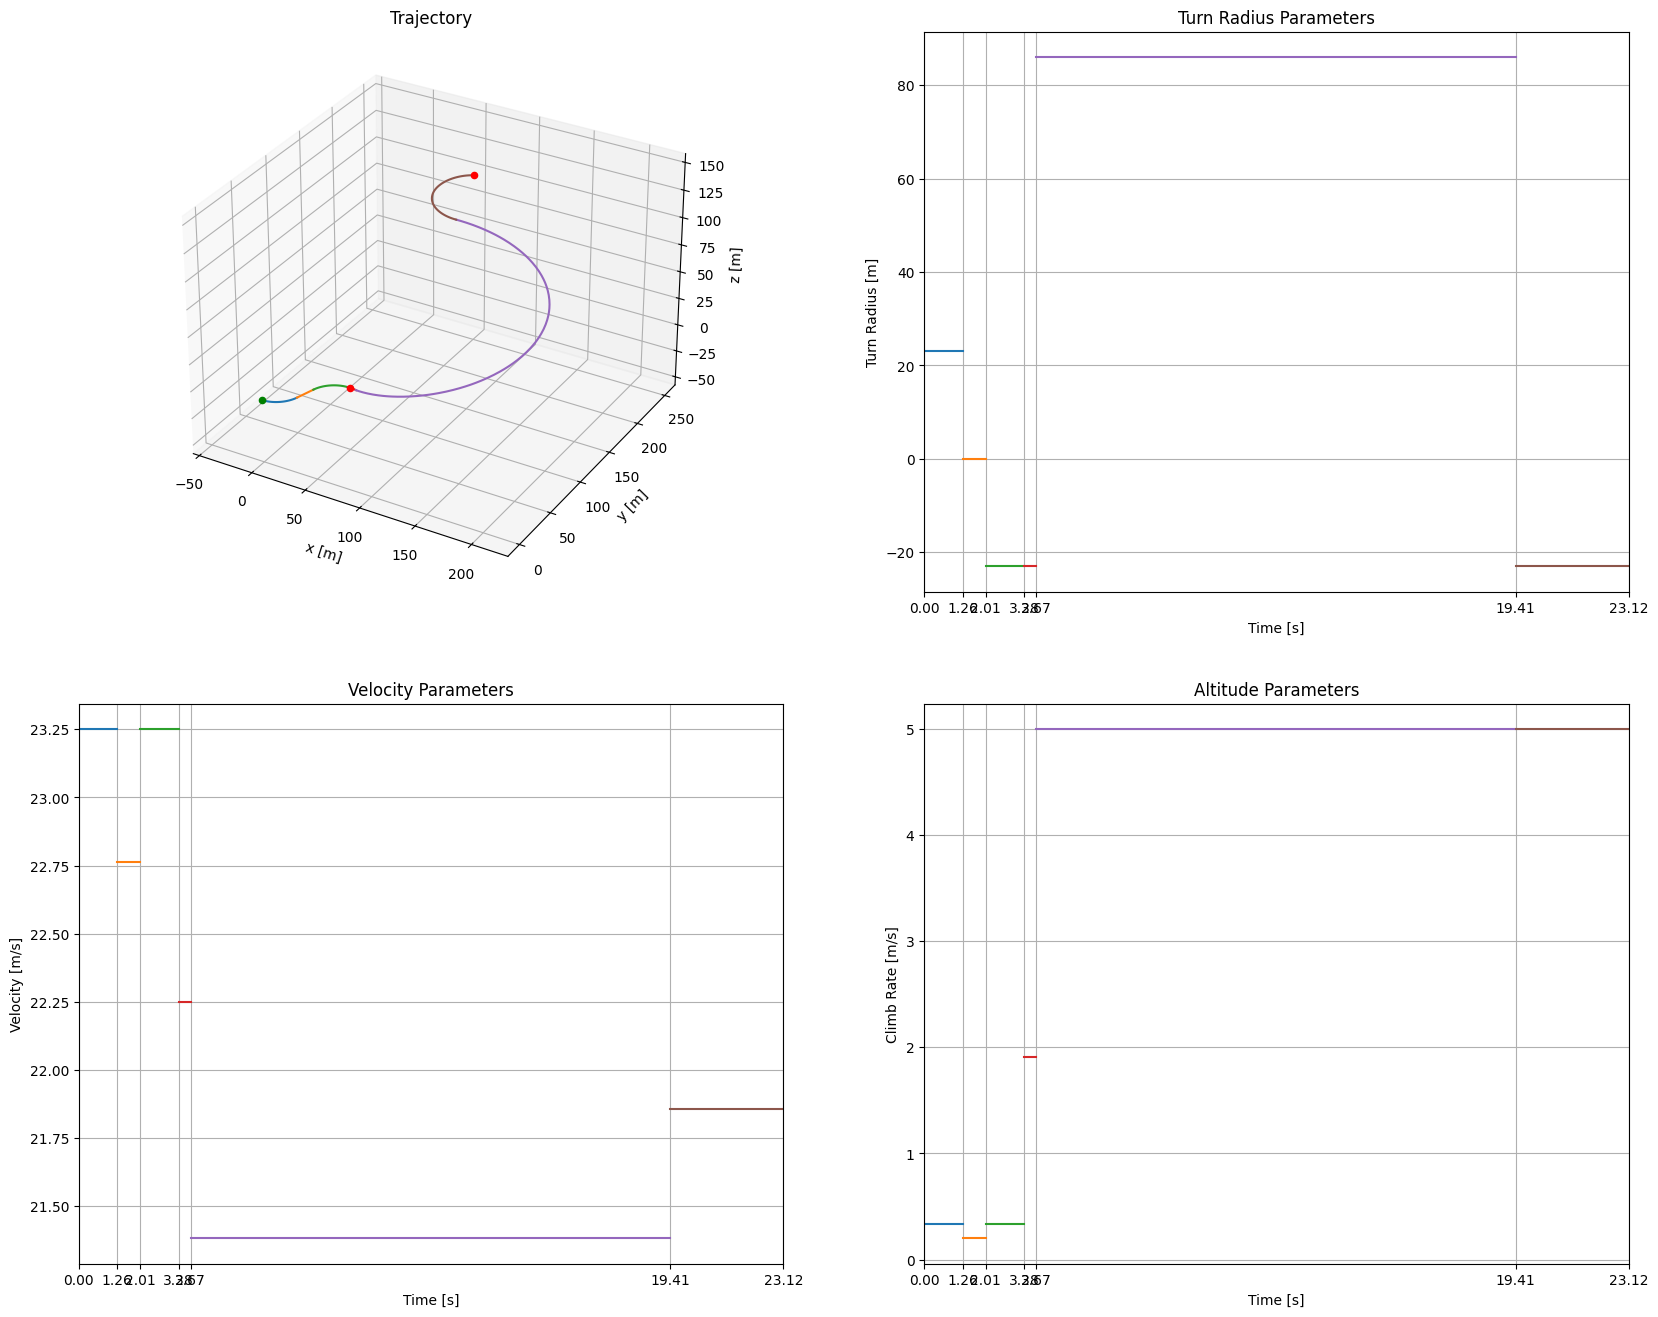

In [7]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
for p in range(total_phases):
    x_temp, y_temp, z_temp, phi_temp = sol.phase[p].state
    ax1.plot(x_temp, y_temp, z_temp)
ax1.scatter(*start_state[0:3], color='green')
for i in range(constraints):
    ax1.scatter(*goal_states[i,0:3], color='red')
ax1.set_aspect('equal', adjustable='datalim')
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_zlabel("z [m]")
ax1.set_title("Trajectory")
ax1.grid(True)

ax2 = fig.add_subplot(2, 2, 2)
for p in range(total_phases):
    t_temp = sol.phase[p].time
    r_inv_temp, V_temp, omega_temp = sol.parameter[3*p:3*p+3]
    if np.abs(r_inv_temp) < np.reciprocal(max_turn):
        r_inv_temp = 0
    if r_inv_temp == 0:
        r_temp = r_inv_temp
    else:
        r_temp = np.reciprocal(r_inv_temp)
    ax2.plot([t_temp[0], t_temp[-1]], [r_temp, r_temp])
ax2.set_xlim(t_sol[0], t_sol[-1])
ax2.set_xticks(t_phase_sol)
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Turn Radius [m]")
ax2.set_title("Turn Radius Parameters")
ax2.grid(True)

ax3 = fig.add_subplot(2, 2, 3)
for p in range(total_phases):
    t_temp = sol.phase[p].time
    r_inv_temp, V_temp, omega_temp = sol.parameter[3*p:3*p+3]
    ax3.plot([t_temp[0], t_temp[-1]], [V_temp, V_temp])
ax3.set_xlim(t_sol[0], t_sol[-1])
ax3.set_xticks(t_phase_sol)
ax3.set_xlabel("Time [s]")
ax3.set_ylabel("Velocity [m/s]")
ax3.set_title("Velocity Parameters")
ax3.grid(True)

ax4 = fig.add_subplot(2, 2, 4)
for p in range(total_phases):
    t_temp = sol.phase[p].time
    r_inv_temp, V_temp, omega_temp = sol.parameter[3*p:3*p+3]
    ax4.plot([t_temp[0], t_temp[-1]], [omega_temp, omega_temp])
ax4.set_xlim(t_sol[0], t_sol[-1])
ax4.set_xticks(t_phase_sol)
ax4.set_xlabel("Time [s]")
ax4.set_ylabel("Climb Rate [m/s]")
ax4.set_title("Altitude Parameters")
ax4.grid(True)